# **Notebook 2 — Model Training**
## Project 8 : Lightweight Transformer Surrogate for Thermal Field Reconstruction
### BASTION-LAB | Procedia Computer Science

This notebook trains all 4 deep learning models on the HEX dataset.
All models receive the same Strategy A input **(B, 3, 64, 128)** and produce **(B, 1, 64, 128)**.

| Model | Type | Params | Role |
|-------|------|--------|------|
| MLP | Fully connected | ~26.9M | Spatial-blind baseline |
| U-Net | CNN encoder-decoder | ~1.93M | Strong DL baseline |
| Tiny ViT | CNN + Transformer | ~0.75M | Main contribution |
| FNO-lite | Fourier Neural Operator | ~1.18M | Physics-oriented baseline |

> **Runtime** : GPU T4 recommended — Runtime → Change runtime type → GPU


## **Step 1 — Environment Setup**

In [1]:
!pip install torch torchvision scipy numpy matplotlib pandas -q

import torch
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch : 2.11.0+cu128
CUDA    : True
GPU     : Tesla T4
VRAM    : 15.6 GB


## **Step 2 — Mount Google Drive and Set Paths**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os

DRIVE_ROOT     = '/content/drive/MyDrive/PaperSurrogate/paperReconstruction'
DATASET_ROOT   = os.path.join(DRIVE_ROOT, 'HEX_dataset')
CHECKPOINT_DIR = os.path.join(DRIVE_ROOT, 'checkpoints')
LOG_DIR        = os.path.join(DRIVE_ROOT, 'logs')

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(LOG_DIR,        exist_ok=True)

# Verify dataset
for split in ['train', 'val', 'test']:
    folder = os.path.join(DATASET_ROOT, split)
    all_f  = [f for f in os.listdir(folder) if f.endswith('.mat')]
    lhs_f  = [f for f in all_f if f.startswith('sample_')]
    hard_f = [f for f in all_f if f.startswith('hard_')]
    if hard_f:
        print(f"  {split:6s}: {len(all_f)} total ({len(lhs_f)} LHS + {len(hard_f)} hard)")
    else:
        print(f"  {split:6s}: {len(all_f)} samples")


Mounted at /content/drive
  train : 4000 samples
  val   : 500 samples
  test  : 550 total (500 LHS + 50 hard)


## **Step 3 — Dataset Loader**
Loads `.mat` files and returns normalized tensors.
Normalization maps all temperatures to **[0, 1]** using T_min=280K, T_max=400K.


In [3]:
import numpy as np
import scipy.io as sio
import torch
from torch.utils.data import Dataset, DataLoader

T_MIN, T_MAX = 280.0, 400.0

# ── Helper: denormalize back to Kelvin ───────────────────────────────────────
def to_kelvin(x):
    """Convert normalized [0,1] tensor or array back to Kelvin."""
    return x * (T_MAX - T_MIN) + T_MIN


class HEXDataset(Dataset):
    """
    Loads HEX .mat samples and returns normalized (X_input, T_field) tensors.

    NORMALIZATION:
        All temperatures are mapped to [0, 1] using fixed physical bounds:
            T_norm = (T - T_MIN) / (T_MAX - T_MIN)
            T_MIN = 280 K  (minimum cold wall temperature)
            T_MAX = 400 K  (maximum hot inlet temperature)
        This ensures all samples are comparable and training is numerically stable.
        np.clip() is applied after normalization as a safety guard against
        rare numerical edge cases where T_field slightly exceeds [T_MIN, T_MAX].

    CHANNELS:
        Channel 0 : normalized sensor temperatures (0 elsewhere)
        Channel 1 : binary sensor mask — no normalization needed
        Channel 2 : normalized T_in broadcast over entire grid

    Args:
        root_dir     (str)      : path to split folder (train/val/test)
        n_sensors    (int|None) : subsample to n_sensors for dropout study
        files_filter (callable) : optional filter on filenames (e.g. LHS only)
    """
    def __init__(self, root_dir, n_sensors=None, files_filter=None):
        all_files = sorted([f for f in os.listdir(root_dir) if f.endswith('.mat')])
        if files_filter is not None:
            all_files = [f for f in all_files if files_filter(f)]
        self.files     = [os.path.join(root_dir, f) for f in all_files]
        self.n_sensors = n_sensors
        # PERF FIX: read every .mat ONCE here and keep the arrays in RAM.
        # Previously __getitem__ called sio.loadmat() on every access, so each
        # epoch re-read all files from Google Drive through the FUSE mount
        # (slow random small-file I/O) -- the real reason one epoch took minutes
        # even for the small U-Net. The whole dataset is < 1 GB, so caching it
        # makes epochs GPU-bound instead of Drive-bound.
        self.cache = []
        for fp in self.files:
            d = sio.loadmat(fp)
            X = d['X_input'].astype(np.float32)
            if X.ndim == 4: X = X.squeeze(0)
            self.cache.append((X.reshape(3, 64, 128),
                               d['T_field'].squeeze().astype(np.float32),
                               d['u_pos'].squeeze(),
                               d['params'].squeeze().astype(np.float32)))
        print(f"  Loaded + cached {len(self.files)} samples from '{root_dir}'")

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        X0, T0, u_pos, params = self.cache[idx]      # from RAM, no disk I/O
        T = T0.copy()
        X = X0.copy()

        # Optional: subsample sensors on-the-fly (for M=8/12 dropout study)
        if self.n_sensors is not None:
            pos = u_pos
            if pos.ndim == 1: pos = pos[np.newaxis, :]
            ch  = np.random.choice(pos.shape[0], self.n_sensors, replace=False)
            pos = pos[ch].astype(int)
            obs = np.array([T[r, c] for r, c in pos], dtype=np.float32)
            X   = np.zeros((3, 64, 128), dtype=np.float32)
            for k, (r, c) in enumerate(pos):
                X[0, r, c] = obs[k]
                X[1, r, c] = 1.0
            X[2, :, :] = float(params[0])

        # Normalize channels 0 and 2 to [0, 1] — channel 1 is already binary
        X[0] = (X[0] - T_MIN) / (T_MAX - T_MIN)
        X[2] = (X[2] - T_MIN) / (T_MAX - T_MIN)
        T    = (T    - T_MIN) / (T_MAX - T_MIN)

        # Safety clip: guard against rare numerical values outside [0, 1]
        X = np.clip(X, 0.0, 1.0)
        T = np.clip(T, 0.0, 1.0)

        return torch.from_numpy(X), torch.from_numpy(T[None, ...])


def get_loaders(batch_size=32, n_sensors=None, num_workers=0):
    """
    Build train, val, test DataLoaders.
    Training loader uses only LHS samples (excludes hard_*.mat).
    """
    loaders = {}
    for split, shuffle in [('train', True), ('val', False), ('test', False)]:
        # Exclude hard cases from training — they are test-only
        filt = (lambda f: f.startswith('sample_')) if split == 'train' else None
        ds   = HEXDataset(os.path.join(DATASET_ROOT, split),
                          n_sensors=n_sensors, files_filter=filt)
        loaders[split] = DataLoader(ds, batch_size=batch_size,
                                    shuffle=shuffle, num_workers=num_workers,
                                    pin_memory=torch.cuda.is_available())
    return loaders['train'], loaders['val'], loaders['test']


# Quick verification
train_loader, val_loader, test_loader = get_loaders(batch_size=32)
X, T = next(iter(train_loader))
print(f"Batch X : {tuple(X.shape)}  range [{X.min():.4f}, {X.max():.4f}]  (should be [0,1])")
print(f"Batch T : {tuple(T.shape)}  range [{T.min():.4f}, {T.max():.4f}]  (should be [0,1])")

# Verify channel semantics
mask_sum = X[:, 1, :, :].sum(dim=(1,2))
print(f"Channel 1 (mask) sum per sample: {mask_sum[:4].tolist()} (expected: ~16)")


  Loaded + cached 4000 samples from '/content/drive/MyDrive/PaperSurrogate/paperReconstruction/HEX_dataset/train'
  Loaded + cached 500 samples from '/content/drive/MyDrive/PaperSurrogate/paperReconstruction/HEX_dataset/val'
  Loaded + cached 550 samples from '/content/drive/MyDrive/PaperSurrogate/paperReconstruction/HEX_dataset/test'
Batch X : (32, 3, 64, 128)  range [0.0000, 1.0000]  (should be [0,1])
Batch T : (32, 1, 64, 128)  range [0.0087, 0.9602]  (should be [0,1])
Channel 1 (mask) sum per sample: [16.0, 16.0, 16.0, 16.0] (expected: ~16)


## **Step 4 — Model Definitions**

All 4 models share the same input/output format.

### Architecture summary

**MLP** — flattens (3×64×128)=24576 values → 4 dense layers → reshape to (64×128).
Spatial-blind: no notion of neighborhood. Tests whether spatial structure matters.

**U-Net** — 3-stage CNN encoder with MaxPool, then 3-stage decoder with skip connections.
Skip connections bypass the bottleneck to preserve fine spatial details.

**Tiny ViT** — CNN encoder (3 stages) → bottleneck (128→64 ch) → flatten to 128 tokens of dim 64
→ **3 Transformer layers** (4 attention heads) → CNN decoder with skip connections.
Self-attention lets every spatial token directly attend to every other token — key for multi-pass coupling.

**FNO-lite** — lift (3→32 ch) → 4 Fourier layers (spectral conv + pointwise conv) → project to output.
Each Fourier layer keeps the 12 lowest frequency modes in each direction.


In [4]:
import torch.nn as nn
import torch.nn.functional as F

# Shared building block used by U-Net and Tiny ViT
class ConvBlock(nn.Module):
    """Conv3x3 -> BN -> ReLU -> Conv3x3 -> BN -> ReLU"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


# ── MLP ──────────────────────────────────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self, ny=64, nx=128):
        super().__init__(); self.ny, self.nx = ny, nx
        self.net = nn.Sequential(
            nn.Linear(3*ny*nx, 1024), nn.BatchNorm1d(1024), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(1024, 512),     nn.BatchNorm1d(512),  nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(512,  256),     nn.BatchNorm1d(256),  nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(256,  ny*nx),   nn.Sigmoid(),
        )
    def forward(self, x):
        return self.net(x.reshape(x.shape[0],-1)).reshape(x.shape[0],1,self.ny,self.nx)


# ── U-Net ─────────────────────────────────────────────────────────────────────
class UNet(nn.Module):
    def __init__(self, in_ch=3, base=32):
        super().__init__()
        self.enc1 = ConvBlock(in_ch, base);   self.enc2 = ConvBlock(base, base*2)
        self.enc3 = ConvBlock(base*2, base*4); self.pool = nn.MaxPool2d(2)
        self.bot  = ConvBlock(base*4, base*8)
        self.up3  = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.dec3 = ConvBlock(base*8,  base*4)
        self.up2  = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.dec2 = ConvBlock(base*4,  base*2)
        self.up1  = nn.ConvTranspose2d(base*2, base,   2, stride=2)
        self.dec1 = ConvBlock(base*2,  base)
        self.head = nn.Sequential(nn.Conv2d(base, 1, 1), nn.Sigmoid())

    def forward(self, x):
        e1 = self.enc1(x); e2 = self.enc2(self.pool(e1)); e3 = self.enc3(self.pool(e2))
        b  = self.bot(self.pool(e3))
        d3 = self.dec3(torch.cat([self.up3(b),  e3], 1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], 1))
        return self.head(self.dec1(torch.cat([self.up1(d2), e1], 1)))


# ── Tiny ViT (CNN + Transformer hybrid) ──────────────────────────────────────
class TinyViT(nn.Module):
    """
    Hybrid CNN + Transformer for thermal field reconstruction.
    CNN encoder extracts local features, Transformer models global
    pass-to-pass dependencies via self-attention, CNN decoder
    reconstructs the full field with skip connections.
    Hyperparameters: d=64, n_heads=4, n_layers=3.
    """
    def __init__(self, in_ch=3, base=32, d=64, n_heads=4, n_layers=3):
        super().__init__()
        # CNN Encoder
        self.enc1 = ConvBlock(in_ch, base); self.enc2 = ConvBlock(base, base*2)
        self.enc3 = ConvBlock(base*2, base*4); self.pool = nn.MaxPool2d(2)
        self.bot  = nn.Sequential(
            nn.Conv2d(base*4, d, 3, padding=1, bias=False), nn.BatchNorm2d(d), nn.GELU(),
            nn.Conv2d(d,      d, 3, padding=1, bias=False), nn.BatchNorm2d(d), nn.GELU(),
        )
        # Transformer: 128 tokens of dim d=64, 3 layers, 4 heads
        self.pos_emb = nn.Parameter(torch.zeros(1, 128, d))
        nn.init.trunc_normal_(self.pos_emb, std=0.02)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d, nhead=n_heads, dim_feedforward=d*2,
            dropout=0.1, activation='gelu', batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(d)
        # CNN Decoder with skip connections
        self.proj = nn.Conv2d(d, base*4, 1, bias=False)
        self.up3  = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.dec3 = ConvBlock(base*2 + base*4, base*2)
        self.up2  = nn.ConvTranspose2d(base*2, base,   2, stride=2)
        self.dec2 = ConvBlock(base   + base*2, base)
        self.up1  = nn.ConvTranspose2d(base,   base//2, 2, stride=2)
        self.dec1 = ConvBlock(base//2 + base,  base//2)
        self.head = nn.Sequential(nn.Conv2d(base//2, 1, 1), nn.Sigmoid())

    def forward(self, x):
        e1 = self.enc1(x); e2 = self.enc2(self.pool(e1)); e3 = self.enc3(self.pool(e2))
        b  = self.bot(self.pool(e3)); B, C, H, W = b.shape
        tok  = self.norm(self.transformer(b.flatten(2).permute(0,2,1) + self.pos_emb))
        feat = self.proj(tok.permute(0,2,1).view(B, C, H, W))
        d3 = self.dec3(torch.cat([self.up3(feat), e3], 1))
        d2 = self.dec2(torch.cat([self.up2(d3),   e2], 1))
        return self.head(self.dec1(torch.cat([self.up1(d2), e1], 1)))


# ── FNO-lite ──────────────────────────────────────────────────────────────────
class SpectralConv2d(nn.Module):
    def __init__(self, i, o, m1=12, m2=12):
        super().__init__(); s = 1/(i*o)
        self.W1 = nn.Parameter(s*torch.randn(i,o,m1,m2))
        self.W2 = nn.Parameter(s*torch.randn(i,o,m1,m2)); self.m1, self.m2 = m1, m2
    def forward(self, x):
        B,_,NY,NX = x.shape; xf = torch.fft.rfft2(x)
        out = torch.zeros(B,self.W1.shape[1],NY,NX//2+1,dtype=torch.complex64,device=x.device)
        out[:,:,:self.m1,:self.m2] = torch.einsum(
            'bixy,ioxy->boxy', xf[:,:,:self.m1,:self.m2], torch.complex(self.W1,self.W2))
        return torch.fft.irfft2(out, s=(NY,NX))

class FNOLite(nn.Module):
    def __init__(self, in_ch=3, d=32, n_layers=4, m1=12, m2=12):
        super().__init__(); self.lift = nn.Conv2d(in_ch, d, 1)
        self.spec = nn.ModuleList([SpectralConv2d(d,d,m1,m2) for _ in range(n_layers)])
        self.pw   = nn.ModuleList([nn.Conv2d(d,d,1) for _ in range(n_layers)])
        self.bn   = nn.ModuleList([nn.BatchNorm2d(d) for _ in range(n_layers)])
        self.proj = nn.Sequential(nn.Conv2d(d,d//2,1), nn.GELU(), nn.Conv2d(d//2,1,1), nn.Sigmoid())
    def forward(self, x):
        x = self.lift(x)
        for s, p, b in zip(self.spec, self.pw, self.bn): x = F.gelu(b(s(x)+p(x)))
        return self.proj(x)


# Summary
def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)

print("="*45)
print(f"  {'Model':<15} {'Parameters':>12}")
print("="*45)
for name, cls in [('MLP',MLP),('U-Net',UNet),('Tiny ViT',TinyViT),('FNO-lite',FNOLite)]:
    m = cls()
    print(f"  {name:<15} {count_params(m):>12,}")
print("="*45)

# Forward pass sanity check
x_t = torch.randn(2, 3, 64, 128)
for name, cls in [('MLP',MLP),('U-Net',UNet),('Tiny ViT',TinyViT),('FNO-lite',FNOLite)]:
    m = cls().eval()
    with torch.no_grad(): out = m(x_t)
    assert out.shape == (2,1,64,128), f"Shape error for {name}: {out.shape}"
    print(f"  {name:<12} {tuple(x_t.shape)} -> {tuple(out.shape)}  OK")


  Model             Parameters
  MLP               27,931,904
  U-Net              1,927,009
  Tiny ViT             752,353
  FNO-lite           1,184,801


/tmp/ipykernel_3764/778312089.py:80: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)


  MLP          (2, 3, 64, 128) -> (2, 1, 64, 128)  OK
  U-Net        (2, 3, 64, 128) -> (2, 1, 64, 128)  OK
  Tiny ViT     (2, 3, 64, 128) -> (2, 1, 64, 128)  OK
  FNO-lite     (2, 3, 64, 128) -> (2, 1, 64, 128)  OK


## **Step 5 — Training Infrastructure**
Loss = **0.8 × MSE + 0.2 × MAE** (computed on normalized [0,1] fields).
MSE penalizes large errors (hotspot detection). MAE gives stable gradients.
Optimizer: AdamW + CosineAnnealingLR + early stopping (patience=40).


In [5]:
import time, csv

class ReconLoss(nn.Module):
    def __init__(self): super().__init__(); self.mse=nn.MSELoss(); self.mae=nn.L1Loss()
    def forward(self, p, t): return 0.8*self.mse(p,t) + 0.2*self.mae(p,t)

def metrics_K(pred, target):
    """MAE and RMSE in Kelvin (denormalized)."""
    p = pred   * (T_MAX - T_MIN) + T_MIN
    t = target * (T_MAX - T_MIN) + T_MIN
    return (p-t).abs().mean().item(), ((p-t)**2).mean().sqrt().item()


def train_model(model_name, model_cls, epochs=200, batch_size=32, patience=40):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model  = model_cls().to(device)
    print(f"\n{'='*50}")
    print(f"  Training : {model_name}  ({count_params(model)/1e6:.2f}M params)")
    print(f"  Device   : {device}   Epochs: {epochs}   Patience: {patience}")
    print(f"{'='*50}")

    # Reuse the loaders built once at module load (dataset cached in RAM),
    # instead of re-reading the dataset from Drive for every model.
    global train_loader, val_loader
    optim  = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    sched  = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=epochs, eta_min=1e-5)
    crit   = ReconLoss()
    ckpt   = os.path.join(CHECKPOINT_DIR, f'{model_name}_best.pth')
    log_f  = open(os.path.join(LOG_DIR, f'{model_name}.csv'), 'w', newline='')
    writer = csv.writer(log_f)
    writer.writerow(['epoch','train_loss','val_loss','val_mae_K','val_rmse_K','lr'])

    best, patience_ct = float('inf'), 0

    for epoch in range(1, epochs+1):
        # Training phase
        model.train(); t_loss = 0.0
        for X, T in train_loader:
            X, T = X.to(device), T.to(device)
            optim.zero_grad(set_to_none=True)
            loss = crit(model(X), T)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optim.step()
            t_loss += loss.item()
        t_loss /= len(train_loader)

        # Validation phase
        model.eval(); v_loss = v_mae = v_rmse = 0.0
        with torch.no_grad():
            for X, T in val_loader:
                X, T = X.to(device), T.to(device)
                pred    = model(X)
                v_loss += crit(pred, T).item()
                m, r    = metrics_K(pred, T); v_mae += m; v_rmse += r
        v_loss /= len(val_loader); v_mae /= len(val_loader); v_rmse /= len(val_loader)
        sched.step()
        lr = optim.param_groups[0]['lr']

        if epoch % 10 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{epochs} | train={t_loss:.5f} | "
                  f"val={v_loss:.5f} | MAE={v_mae:.3f}K | RMSE={v_rmse:.3f}K | lr={lr:.2e}")
        writer.writerow([epoch, f'{t_loss:.6f}', f'{v_loss:.6f}',
                         f'{v_mae:.4f}', f'{v_rmse:.4f}', f'{lr:.2e}'])

        if v_loss < best:
            best = v_loss; patience_ct = 0
            torch.save({'epoch': epoch, 'state_dict': model.state_dict(),
                        'val_loss': v_loss, 'val_mae_K': v_mae}, ckpt)
        else:
            patience_ct += 1
            if patience_ct >= patience:
                print(f"  Early stopping at epoch {epoch}")
                break

    log_f.close()
    print(f"  Best val MAE : {best:.6f}")
    print(f"  Checkpoint   : {ckpt}")
    return ckpt

## **Step 6 — Train All Models**
Models are trained sequentially. Expected time on Colab T4: ~45 minutes total.
Checkpoints are saved to Drive after each improvement in validation loss.


In [6]:
results_summary = {}

for model_name, model_cls in [
    ('mlp',  MLP),
    ('unet', UNet),
    ('vit',  TinyViT),
    ('fno',  FNOLite),
]:
    ckpt = train_model(model_name, model_cls, epochs=200, batch_size=32, patience=40)
    results_summary[model_name] = ckpt

print("\nAll models trained:")
for name, ckpt in results_summary.items():
    c = torch.load(ckpt, weights_only=False, map_location='cpu')
    print(f"  {name:<6} epoch={c['epoch']:3d}  val_mae={c['val_mae_K']:.3f}K")



  Training : mlp  (27.93M params)
  Device   : cuda   Epochs: 200   Patience: 40
  Epoch   1/200 | train=0.02363 | val=0.01783 | MAE=7.157K | RMSE=10.151K | lr=1.00e-03
  Epoch  10/200 | train=0.01409 | val=0.03321 | MAE=12.019K | RMSE=15.346K | lr=9.94e-04
  Epoch  20/200 | train=0.01135 | val=0.03909 | MAE=13.370K | RMSE=17.327K | lr=9.76e-04
  Epoch  30/200 | train=0.00948 | val=0.04269 | MAE=13.712K | RMSE=18.741K | lr=9.46e-04
  Epoch  40/200 | train=0.00841 | val=0.02009 | MAE=7.548K | RMSE=11.417K | lr=9.05e-04
  Early stopping at epoch 41
  Best val MAE : 0.017831
  Checkpoint   : /content/drive/MyDrive/PaperSurrogate/paperReconstruction/checkpoints/mlp_best.pth

  Training : unet  (1.93M params)
  Device   : cuda   Epochs: 200   Patience: 40
  Epoch   1/200 | train=0.01327 | val=0.00905 | MAE=4.373K | RMSE=5.619K | lr=1.00e-03
  Epoch  10/200 | train=0.00548 | val=0.00607 | MAE=3.091K | RMSE=4.055K | lr=9.94e-04
  Epoch  20/200 | train=0.00484 | val=0.00405 | MAE=2.029K | RMS

/tmp/ipykernel_3764/778312089.py:80: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)


  Epoch   1/200 | train=0.01800 | val=0.00892 | MAE=4.272K | RMSE=5.683K | lr=1.00e-03
  Epoch  10/200 | train=0.00474 | val=0.00245 | MAE=1.352K | RMSE=1.894K | lr=9.94e-04
  Epoch  20/200 | train=0.00424 | val=0.00281 | MAE=1.546K | RMSE=2.063K | lr=9.76e-04
  Epoch  30/200 | train=0.00398 | val=0.00500 | MAE=2.581K | RMSE=3.535K | lr=9.46e-04
  Epoch  40/200 | train=0.00376 | val=0.00443 | MAE=2.191K | RMSE=3.719K | lr=9.05e-04
  Epoch  50/200 | train=0.00318 | val=0.00289 | MAE=1.580K | RMSE=2.153K | lr=8.55e-04
  Epoch  60/200 | train=0.00289 | val=0.00272 | MAE=1.481K | RMSE=2.137K | lr=7.96e-04
  Epoch  70/200 | train=0.00269 | val=0.00244 | MAE=1.338K | RMSE=1.915K | lr=7.30e-04
  Epoch  80/200 | train=0.00266 | val=0.00171 | MAE=0.968K | RMSE=1.327K | lr=6.58e-04
  Epoch  90/200 | train=0.00230 | val=0.00136 | MAE=0.765K | RMSE=1.238K | lr=5.82e-04
  Epoch 100/200 | train=0.00234 | val=0.00127 | MAE=0.717K | RMSE=1.152K | lr=5.05e-04
  Epoch 110/200 | train=0.00195 | val=0.001

## **Step 7 — Training Curves**

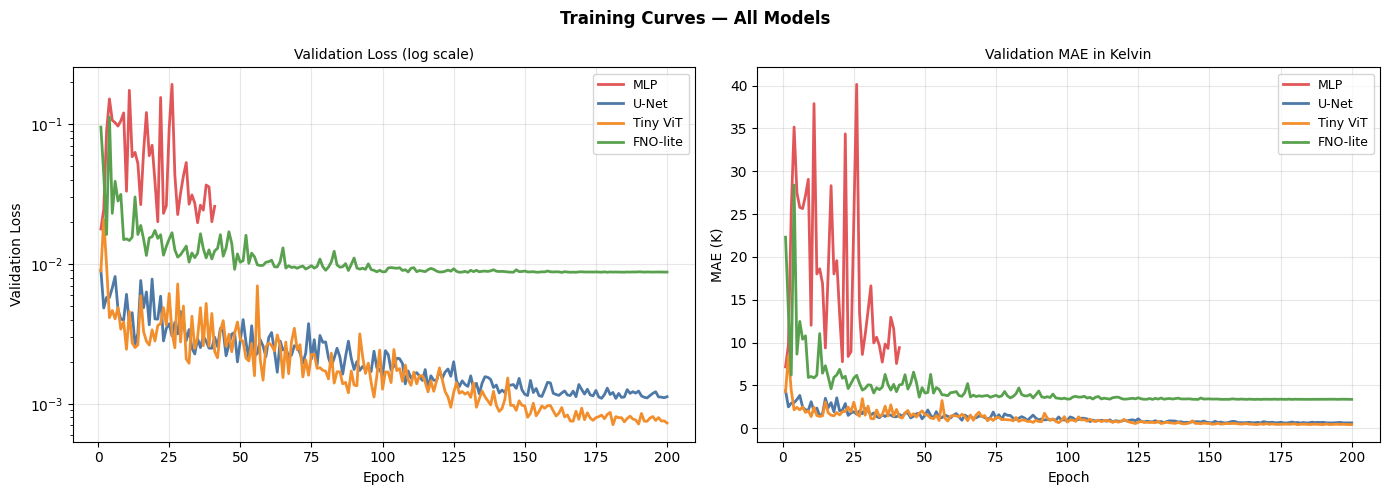

Saved: /content/drive/MyDrive/PaperSurrogate/paperReconstruction/training_curves.png


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Curves — All Models', fontsize=12, fontweight='bold')

colors = {'mlp':'#e15759', 'unet':'#4e79a7', 'vit':'#f28e2b', 'fno':'#59a14f'}
labels = {'mlp':'MLP', 'unet':'U-Net', 'vit':'Tiny ViT', 'fno':'FNO-lite'}

for name in ['mlp', 'unet', 'vit', 'fno']:
    log_path = os.path.join(LOG_DIR, f'{name}.csv')
    if not os.path.exists(log_path): continue
    df = pd.read_csv(log_path)
    axes[0].plot(df['epoch'], df['val_loss'],   label=labels[name], color=colors[name], lw=2)
    axes[1].plot(df['epoch'], df['val_mae_K'],  label=labels[name], color=colors[name], lw=2)

for ax, ylabel, title in zip(axes,
    ['Validation Loss', 'MAE (K)'],
    ['Validation Loss (log scale)', 'Validation MAE in Kelvin']):
    ax.set_xlabel('Epoch', fontsize=10); ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=10); ax.legend(fontsize=9); ax.grid(alpha=0.3)
axes[0].set_yscale('log')

plt.tight_layout()
path = os.path.join(DRIVE_ROOT, 'training_curves.png')
plt.savefig(path, dpi=130, bbox_inches='tight')
plt.show()
print(f"Saved: {path}")
